libraries imorting

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

collecting data & processing

In [3]:
# loarding the csv data to pandas dataframe
gold_data =pd.read_csv('/content/gold_model_dataset_2015_2025.csv')

print first 5 data

In [4]:
# print data of starting 0 to 4
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-06-01,2111.729980,114.000000,162.880005,16.00,1.095794
2,2015-06-02,2109.600098,114.459999,165.440002,16.07,1.092299
3,2015-06-03,2114.070068,113.639999,161.360001,15.83,1.115001
4,2015-06-04,2095.840088,112.839996,157.279999,15.48,1.125784


In [6]:
# print last 5 data
gold_data.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2522,2025-06-13,5976.970215,316.290009,80.220001,32.970001,1.160025
2523,2025-06-16,6033.109863,311.779999,78.589996,33.029999,1.155668
2524,2025-06-17,5982.720215,311.940002,82.300003,33.740002,1.155135
2525,2025-06-18,5980.870117,310.260010,82.269997,33.270000,1.148264
2526,2025-06-20,5967.839844,310.130005,83.120003,32.720001,1.151278


In [7]:
#total raws of data set
gold_data.shape

(2527, 6)

In [8]:
#getting sum basic information about the data set
gold_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2527 entries, 0 to 2526
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2526 non-null   object 
 1   SPX      2526 non-null   float64
 2   GLD      2526 non-null   float64
 3   USO      2526 non-null   float64
 4   SLV      2526 non-null   float64
 5   EUR/USD  2526 non-null   float64
dtypes: float64(5), object(1)
memory usage: 118.6+ KB


In [9]:
# checkin the number of check missing values
gold_data.isnull().sum()

,0
Date,1
SPX,1
GLD,1
USO,1
SLV,1
EUR/USD,1


In [10]:
#getting statistical measures of data
gold_data.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2526.000000,2526.000000,2526.000000,2526.000000,2526.000000
mean,3519.880051,158.064778,77.604549,19.333535,1.117931
std,1162.821209,44.113391,24.561073,4.726707,0.052820
min,1829.079956,100.500000,17.040001,11.210000,0.959619
25%,2562.730103,121.282499,67.139999,15.500000,1.083550
50%,3241.824951,158.484993,77.755001,17.685000,1.114318
75%,4369.669922,178.455002,91.740002,22.530001,1.155064
max,6144.149902,316.290009,165.440002,33.740002,1.251001


Correlations : 1.positive correlations 2.nagetive correlations

In [11]:
correlation = gold_data.drop(columns=['Date']).corr()

<Axes: >

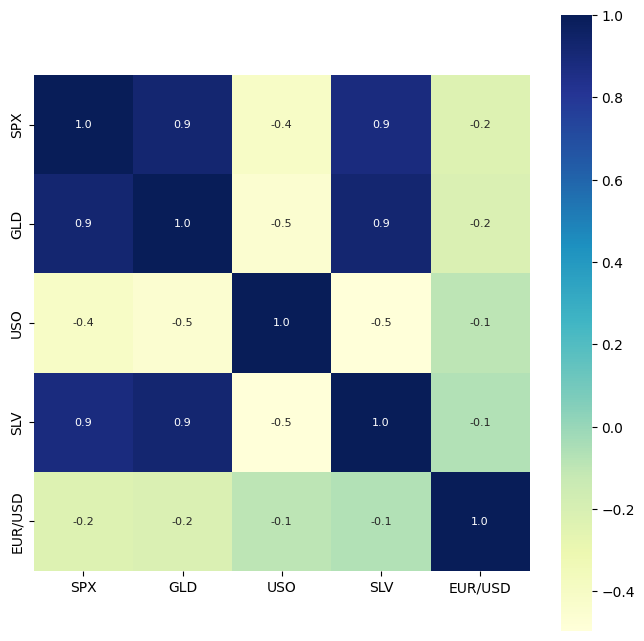

In [12]:
# constructing a heatmap to understand the correlatiom
plt.figure(figsize = (8,8))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f',annot=True, annot_kws={'size':8}, cmap='YlGnBu')

In [13]:
# correlation values of GLD
print(correlation['GLD'])

SPX        0.922786
GLD        1.000000
USO       -0.452085
SLV        0.919854
EUR/USD   -0.213759
Name: GLD, dtype: float64


/tmp/ipython-input-563101706.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gold_data['GLD'],color='green')


<Axes: xlabel='GLD', ylabel='Density'>

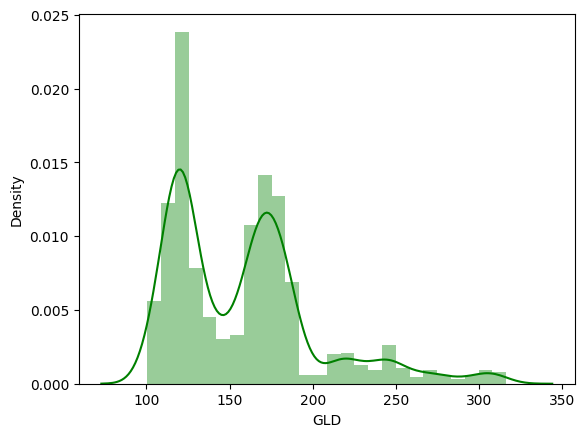

In [14]:
# checking the distribution of the GLD Price
sns.distplot(gold_data['GLD'],color='green')

In [15]:
X = gold_data.drop(['Date','GLD'],axis=1)
Y = gold_data['GLD']

In [16]:
print(X)

              SPX         USO        SLV   EUR/USD
0             NaN         NaN        NaN       NaN
1     2111.729980  162.880005  16.000000  1.095794
2     2109.600098  165.440002  16.070000  1.092299
3     2114.070068  161.360001  15.830000  1.115001
4     2095.840088  157.279999  15.480000  1.125784
...           ...         ...        ...       ...
2522  5976.970215   80.220001  32.970001  1.160025
2523  6033.109863   78.589996  33.029999  1.155668
2524  5982.720215   82.300003  33.740002  1.155135
2525  5980.870117   82.269997  33.270000  1.148264
2526  5967.839844   83.120003  32.720001  1.151278

[2527 rows x 4 columns]


In [17]:
print(Y)

0              NaN
1       114.000000
2       114.459999
3       113.639999
4       112.839996
           ...    
2522    316.290009
2523    311.779999
2524    311.940002
2525    310.260010
2526    310.130005
Name: GLD, Length: 2527, dtype: float64


In [18]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state=2)

In [19]:
regressor = RandomForestRegressor(n_estimators=100)

In [21]:
Y_train = Y_train.fillna(Y_train.mean())

In [22]:
X_train.isnull().sum()

,0
SPX,1
USO,1
SLV,1
EUR/USD,1


In [23]:
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_test.mean())

In [24]:
regressor.fit(X_train, Y_train)

RandomForestRegressor()

In [25]:
#prediction on test data
test_data_prediction = regressor.predict(X_test)

In [26]:
print(test_data_prediction)

[162.88889847 140.51249817 123.21719902 141.07519997 216.48239822
 122.35850006 124.41470001 125.13730072 269.95969208 122.82279991
 151.13559937 109.10939957 187.33359894 256.16790268 162.49619873
 132.90230042 164.68479874 142.07570038 178.07789917 118.26479919
 127.54840103 106.62750084 142.74089958 120.10289978 311.05880402
 112.8545002  120.52660057 177.02179733 117.64400078 124.65680016
 169.02189758 178.49840149 120.9994989  121.02809944 124.88820145
 239.57479813 168.61430054 113.3182003  182.21399918 107.07350075
 141.78649887 223.89110046 178.94920151 125.04550072 178.71639969
 120.83330055 120.4107988  102.91879974 153.92840195 121.41480019
 258.20399948 225.4933992  122.45889946 128.74610229 173.25620193
 187.49609909 119.61890045 173.31739777 167.55610077 180.93269989
 168.36610046 174.44350067 161.57139969 119.91679955 168.6151001
 162.03100052 143.75160034 179.6826033  171.43779907 118.52019989
 102.44389862 192.57019669 161.37860001 215.76239548 179.76159882
 173.176601

In [27]:
# R squared error
error_score = metrics.r2_score(Y_test, test_data_prediction)
print("R squared error : ", error_score)

R squared error :  0.9874608739370127


In [28]:
Y_test = list(Y_test)

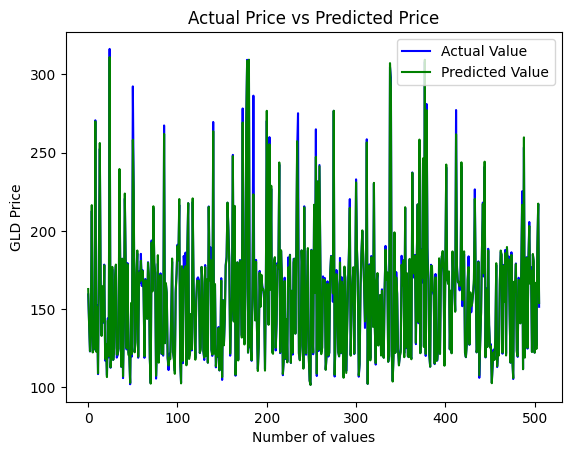

In [31]:
plt.plot(Y_test, color='blue', label = 'Actual Value')
plt.plot(test_data_prediction, color='green', label='Predicted Value')
plt.title('Actual Price vs Predicted Price')
plt.xlabel('Number of values')
plt.ylabel('GLD Price')
plt.legend()
plt.show()